In [1]:
# ============================================================
# PART 1 : ANALYTICAL STEADY-STATE SOLUTION
# ============================================================

import sympy as sp
from IPython.display import display

# ------------------------------------------------------------
# Symbolic Variables
# ------------------------------------------------------------

x_sym = sp.symbols('x', real=True)

D_sym, v_sym = sp.symbols('D v', positive=True)

p_sym = sp.Function('p')

# ------------------------------------------------------------
# Governing Equation
#
# D*d²p/dx² + v*dp/dx = 0
# ------------------------------------------------------------

ode = sp.Eq(
    D_sym * sp.diff(p_sym(x_sym), x_sym, 2)
    +
    v_sym * sp.diff(p_sym(x_sym), x_sym),
    0
)

print("="*60)
print("STEADY-STATE GOVERNING EQUATION")
print("="*60)
display(ode)

# ------------------------------------------------------------
# General Solution
# ------------------------------------------------------------

general_solution = sp.dsolve(ode)

print("\nGeneral Solution:")
display(general_solution)

# ------------------------------------------------------------
# Extract RHS
# ------------------------------------------------------------

p_general = general_solution.rhs

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------

C1_sym, C2_sym = sp.symbols('C1 C2')

# ------------------------------------------------------------
# First Derivative
# ------------------------------------------------------------

dpdx = sp.diff(p_general, x_sym)

# ------------------------------------------------------------
# Boundary Condition 1
#
# x = 0
#
# dp/dx = (1/v)p
# ------------------------------------------------------------

BC1 = sp.Eq(
    dpdx.subs(x_sym, 0),
    (1 / v_sym) * p_general.subs(x_sym, 0)
)

print("\nBoundary Condition 1:")
display(BC1)

# ------------------------------------------------------------
# Boundary Condition 2
#
# x = 1
#
# p = 1
# ------------------------------------------------------------

BC2 = sp.Eq(
    p_general.subs(x_sym, 1),
    1
)

print("\nBoundary Condition 2:")
display(BC2)

# ------------------------------------------------------------
# Solve for Constants
# ------------------------------------------------------------

constants = sp.solve(
    (BC1, BC2),
    (C1_sym, C2_sym),
    dict=True
)[0]

print("\nSolved Constants:")
display(constants)

# ------------------------------------------------------------
# Final Analytical Solution
# ------------------------------------------------------------

analytical_solution = sp.simplify(
    p_general.subs(constants)
)

print("\nFinal Analytical Solution:")
display(analytical_solution)

# ------------------------------------------------------------
# Expanded Form (Optional)
# ------------------------------------------------------------

print("\nExpanded Form:")
display(sp.expand(analytical_solution))

# ------------------------------------------------------------
# Pretty Simplified Form
# ------------------------------------------------------------

print("\nSimplified Form:")
display(sp.factor(analytical_solution))

STEADY-STATE GOVERNING EQUATION


Eq(D*Derivative(p(x), (x, 2)) + v*Derivative(p(x), x), 0)


General Solution:


Eq(p(x), C1 + C2*exp(-v*x/D))


Boundary Condition 1:


...

(-D + (D + v**2)*exp(v*x/D))*exp(v*(1 - x)/D)/(D*exp(v/D) - D + v**2*exp(v/D))


Expanded Form:


-D*exp(v/D)/(D*exp(v/D)*exp(v*x/D) - D*exp(v*x/D) + v**2*exp(v/D)*exp(v*x/D)) + D*exp(v/D)/(D*exp(v/D) - D + v**2*exp(v/D)) + v**2*exp(v/D)/(D*exp(v/D) - D + v**2*exp(v/D))


Simplified Form:


(D*exp(v*x/D) - D + v**2*exp(v*x/D))*exp(v/D)*exp(-v*x/D)/(D*exp(v/D) - D + v**2*exp(v/D))

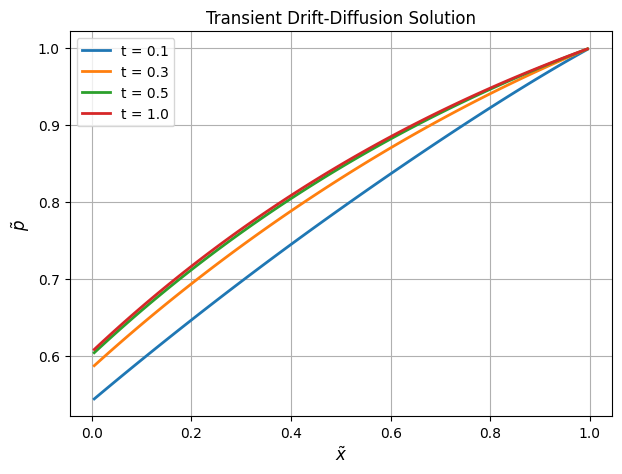

Transient simulation completed.
Final simulation time = 10.0

Robin Boundary Check
----------------------------------------
p(left)         = 0.6083282813178391
dp/dx(left)     = 0.6083282813178391
p(left)/v       = 0.6083282813178391
----------------------------------------


In [2]:
# ============================================================
# PART 2 : TRANSIENT FIPY SOLUTION
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

L = 1.0
nx = 100
dx = L / nx

D_tilde = 1.0
v_tilde = 1.0

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

# ------------------------------------------------------------
# Mesh
# ------------------------------------------------------------

mesh = Grid1D(dx=dx, nx=nx)

x_fipy = mesh.cellCenters[0]

# ------------------------------------------------------------
# Initial Condition
#
# p(x,0) = sin(pi*x)
# ------------------------------------------------------------

p_fipy = CellVariable(
    name=r'$\tilde{p}$',
    mesh=mesh,
    value=np.sin(np.pi * x_fipy.value)
)

# ------------------------------------------------------------
# Right Boundary Condition
#
# p(1,t)=1
# ------------------------------------------------------------

p_fipy.constrain(
    1.0,
    where=mesh.facesRight
)

# ------------------------------------------------------------
# Left Robin Boundary Condition
#
# dp/dx = (1/v_tilde)p
# ------------------------------------------------------------

p_fipy.faceGrad.constrain(
    (((1.0 / v_tilde) * p_fipy.faceValue,),),
    where=mesh.facesLeft
)

# ------------------------------------------------------------
# Governing Equation
#
# dp/dt = D*d²p/dx² + v*dp/dx
# ------------------------------------------------------------

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=D_tilde)
    +
    ConvectionTerm(coeff=(v_tilde,))
)

# ------------------------------------------------------------
# Time Marching
# ------------------------------------------------------------

plot_times = [0.1,0.3,0.5,1.0]

time = 0.0

plt.figure(figsize=(7,5))

for step in range(steps):

    eq.solve(
        var=p_fipy,
        dt=dt
    )

    time += dt

    for t in plot_times:

        if abs(time-t) < dt/2:

            plt.plot(
                x_fipy.value,
                p_fipy.value,
                linewidth=2,
                label=f"t = {time:.1f}"
            )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.xlabel(r'$\tilde{x}$',fontsize=12)
plt.ylabel(r'$\tilde{p}$',fontsize=12)

plt.title("Transient Drift-Diffusion Solution")

plt.grid(True)
plt.legend()

plt.show()

# ------------------------------------------------------------
# Save Numerical Steady-State Solution
# ------------------------------------------------------------

x_numerical = x_fipy.value.copy()

p_numerical = p_fipy.value.copy()

print("="*60)
print("Transient simulation completed.")
print("Final simulation time =", final_time)
print("="*60)

# ------------------------------------------------------------
# Verify Robin Boundary Condition
# ------------------------------------------------------------

print("\nRobin Boundary Check")
print("-"*40)

print("p(left)         =", p_fipy.faceValue.value[0])
print("dp/dx(left)     =", p_fipy.faceGrad[0].value[0])
print("p(left)/v       =", p_fipy.faceValue.value[0]/v_tilde)

print("-"*40)

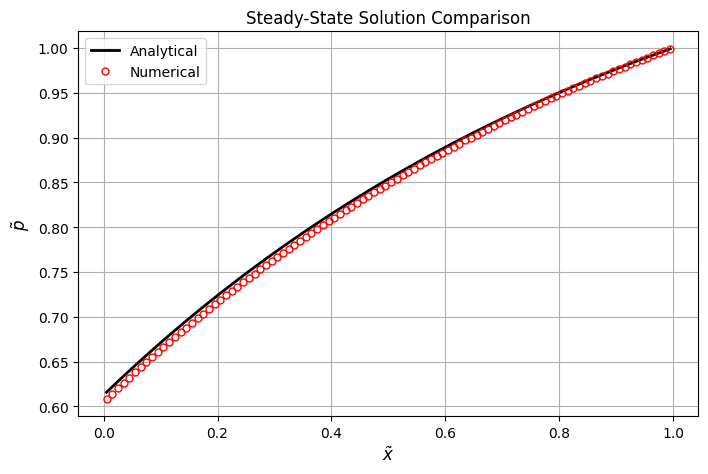

Steady-State Validation
Maximum Error = 7.547947e-03
L2 Error      = 5.404533e-03

Boundary Condition Check
--------------------------------------------------
Left Robin Boundary
dp/dx(left)      = 0.6083282813178391
p(left)/v        = 0.6083282813178391
--------------------------------------------------
Right Dirichlet Boundary
Numerical p(1)   = 1.0
Expected         = 1.0
--------------------------------------------------


In [3]:
# ============================================================
# PART 3 : NUMERICAL vs ANALYTICAL COMPARISON
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create Numerical Function from SymPy Expression
# ------------------------------------------------------------

analytical_func = sp.lambdify(
    (x_sym, D_sym, v_sym),
    analytical_solution,
    modules="numpy"
)

# ------------------------------------------------------------
# Evaluate Analytical Solution
# ------------------------------------------------------------

p_analytical = analytical_func(
    x_numerical,
    D_tilde,
    v_tilde
)

# ------------------------------------------------------------
# Numerical Solution
# ------------------------------------------------------------

p_numerical = np.array(p_numerical)

# ------------------------------------------------------------
# Error Analysis
# ------------------------------------------------------------

error = np.abs(p_numerical - p_analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

# ------------------------------------------------------------
# Plot Comparison
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    x_numerical,
    p_analytical,
    'k-',
    linewidth=2,
    label='Analytical'
)

plt.plot(
    x_numerical,
    p_numerical,
    'ro',
    markersize=5,
    fillstyle='none',
    label='Numerical'
)

plt.xlabel(r'$\tilde{x}$', fontsize=12)
plt.ylabel(r'$\tilde{p}$', fontsize=12)

plt.title("Steady-State Solution Comparison")

plt.grid(True)
plt.legend()

plt.show()

# ------------------------------------------------------------
# Print Errors
# ------------------------------------------------------------

print("="*60)
print("Steady-State Validation")
print("="*60)

print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

print("="*60)

# ------------------------------------------------------------
# Verify Boundary Conditions
# ------------------------------------------------------------

print("\nBoundary Condition Check")

print("-"*50)

print("Left Robin Boundary")

print("dp/dx(left)      =", p_fipy.faceGrad[0].value[0])

print("p(left)/v        =", p_fipy.faceValue.value[0]/v_tilde)

print("-"*50)

print("Right Dirichlet Boundary")

print("Numerical p(1)   =", p_fipy.faceValue.value[-1])

print("Expected         = 1.0")

print("-"*50)

    nx          dx        Maximum Error         L2 Error     
    50       0.02000       6.492861e-03       4.146451e-03   
   100       0.01000       7.547947e-03       5.404533e-03   
   200       0.00500       1.638151e-02       1.205310e-02   
   400       0.00250       4.388342e-02       3.250247e-02   


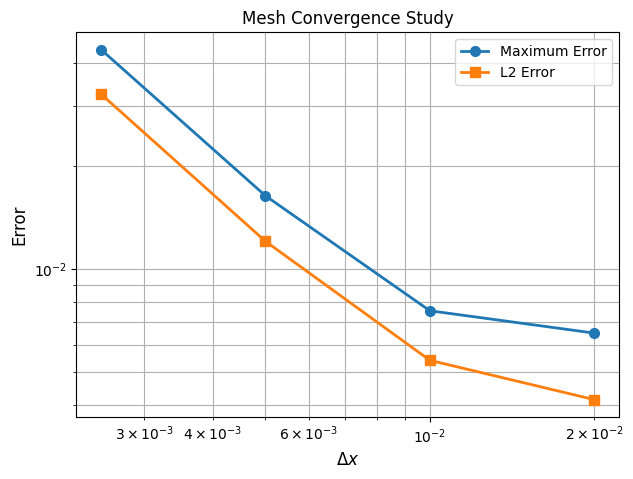

In [4]:
# ============================================================
# PART 4 : MESH CONVERGENCE STUDY
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

L = 1.0

D_tilde = 1.0
v_tilde = 1.0

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

mesh_sizes = [50, 100, 200, 400]

# ------------------------------------------------------------
# Analytical Function
# ------------------------------------------------------------

analytical_func = sp.lambdify(
    (x_sym, D_sym, v_sym),
    analytical_solution,
    "numpy"
)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

dx_list = []
max_error_list = []
l2_error_list = []

print("="*75)
print("{:^10s} {:^12s} {:^18s} {:^18s}".format(
    "nx","dx","Maximum Error","L2 Error"))
print("="*75)

# ------------------------------------------------------------
# Loop Over Mesh Sizes
# ------------------------------------------------------------

for nx in mesh_sizes:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x_fipy = mesh.cellCenters[0]

    p_fipy = CellVariable(
        mesh=mesh,
        value=np.sin(np.pi*x_fipy.value)
    )

    # Right Dirichlet BC
    p_fipy.constrain(
        1.0,
        where=mesh.facesRight
    )

    # Left Robin BC
    p_fipy.faceGrad.constrain(
        (((1.0/v_tilde)*p_fipy.faceValue,),),
        where=mesh.facesLeft
    )

    # PDE
    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=D_tilde)
        +
        ConvectionTerm(coeff=(v_tilde,))
    )

    # Time Marching
    for step in range(steps):

        eq.solve(
            var=p_fipy,
            dt=dt
        )

    # Numerical Solution
    x_num = x_fipy.value
    p_num = p_fipy.value

    # Analytical Solution
    p_exact = analytical_func(
        x_num,
        D_tilde,
        v_tilde
    )

    # Errors
    error = np.abs(p_num-p_exact)

    max_error = np.max(error)

    l2_error = np.sqrt(np.mean(error**2))

    dx_list.append(dx)
    max_error_list.append(max_error)
    l2_error_list.append(l2_error)

    print("{:^10d} {:^12.5f} {:^18.6e} {:^18.6e}".format(
        nx,
        dx,
        max_error,
        l2_error
    ))

print("="*75)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.loglog(
    dx_list,
    max_error_list,
    'o-',
    linewidth=2,
    markersize=7,
    label='Maximum Error'
)

plt.loglog(
    dx_list,
    l2_error_list,
    's-',
    linewidth=2,
    markersize=7,
    label='L2 Error'
)

plt.xlabel(r'$\Delta x$', fontsize=12)
plt.ylabel("Error", fontsize=12)

plt.title("Mesh Convergence Study")

plt.grid(True, which='both')

plt.legend()

plt.show()